 importing libraries that are required for analysis

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [24]:
# Importing the dataset containing information about Indian kids' screen time 
df=pd.read_csv("Indian_Kids_Screen_Time.csv")
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


# Data preprocessing and cleaning


In [26]:
#shape of the dataset
df.shape # 9712-->rows,8-->columns

(9712, 8)

In [27]:
# Display the first five records to understand dataset structure
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [28]:
#to print last 5 rows from the dataset
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [29]:
#describing the dataset
df.describe() 

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


from above we analyse that
Age: Children in the dataset are between 8 and 18 years old, with an average age of about 13 years.
Avg_Daily_Screen_Time_hr: Kids spend an average of 4.3 hours per day on screens, ranging from 0 to nearly 14 hours.
Educational_to_Recreational_Ratio: On average, about 42% of screen time is educational, with most kids between 0.3 and 0.6.


In [31]:
#dataset information which gives columns,non-null count and dtype(datatype)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [32]:
#dataset columns
df.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')

In [33]:
#to check null values count
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [34]:
#to check duplicates 
df.duplicated().sum()

44

In [35]:
#droping (removing) duplicates
df.drop_duplicates(inplace=True)

In [36]:
#calculating percentage of missing values
missing_value_percentage=df['Health_Impacts'].isnull().mean()*100
print(f"Percentage of missing values in 'Health_Impacts': {missing_value_percentage}%")

Percentage of missing values in 'Health_Impacts': 32.892014894497315%


In [37]:
#fillna is used to fill the missing values with unknown
df["Health_Impacts"].fillna("Unknown", inplace=True)


C:\Users\tasne\AppData\Local\Temp\ipykernel_30128\4109460620.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [38]:
df #the rows are reduced from 9712 to 9668 because we removed duplicates

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,Unknown,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


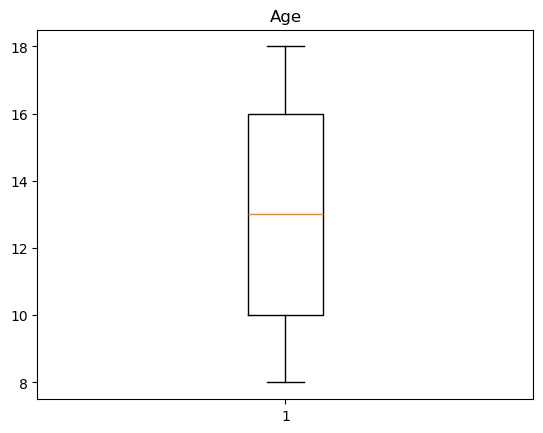

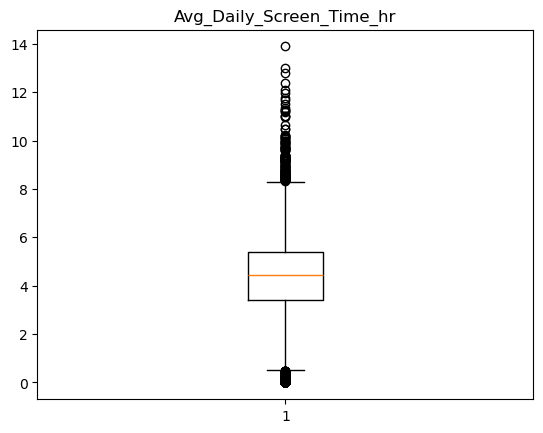

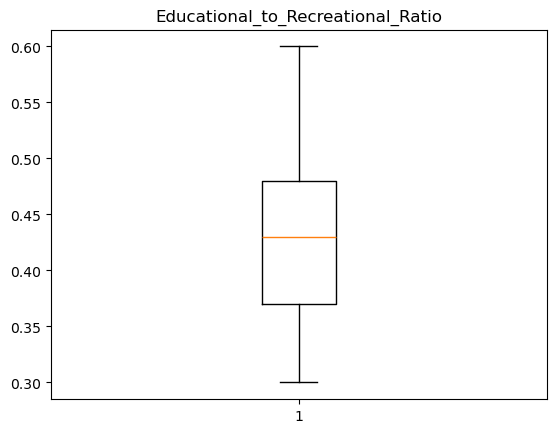

In [39]:
for col in df.columns:
    if df[col].dtypes!="object" and df[col].dtypes!='bool':
        plt.boxplot(df[col])
        plt.title(col)
        plt.show()

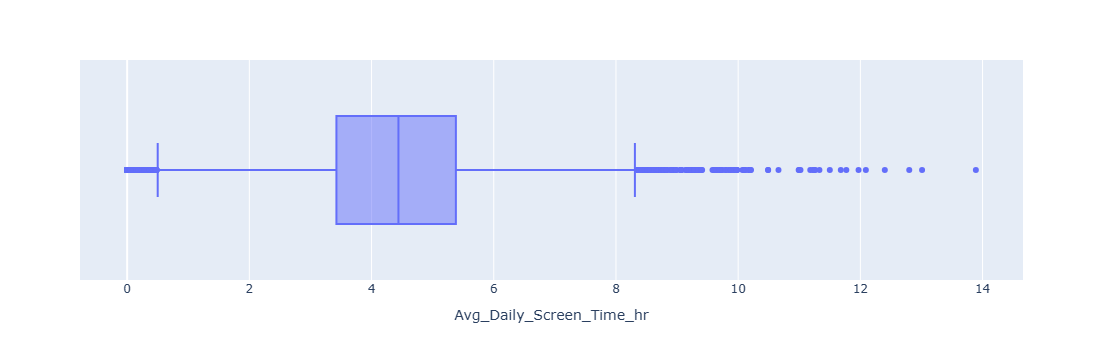

In [40]:
fig=px.box(df,x='Avg_Daily_Screen_Time_hr')
fig.show()

Through the box plot, we observe that "Avg_Daily_Screen_Time_hr" has many outliers.
We should not remove them because it may cause loss of valuable data.

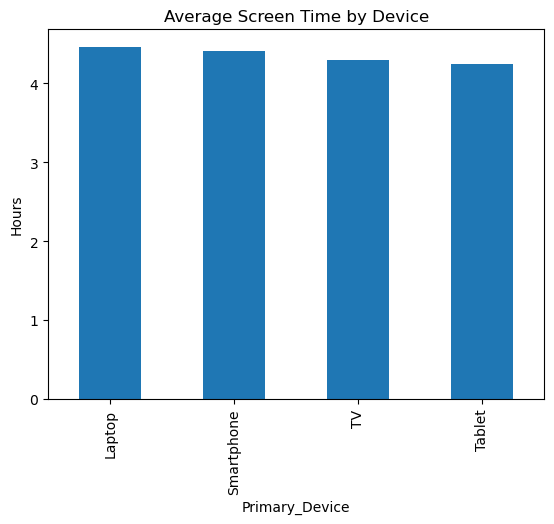

In [43]:
avg_device = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean()

avg_device.plot(kind='bar')
plt.title("Average Screen Time by Device")
plt.ylabel("Hours")
plt.show()

from above barplot we analyse that
"Smartphones" have the highest average daily screen time (14 hours), 
making them the primary source of user engagement.
"TV" is second highest (13 hours),showing it is still a major source of usage after "smartphones".
"Tablet" has Moderate (12 hours).
"Laptop" has Lowest (8 hours).


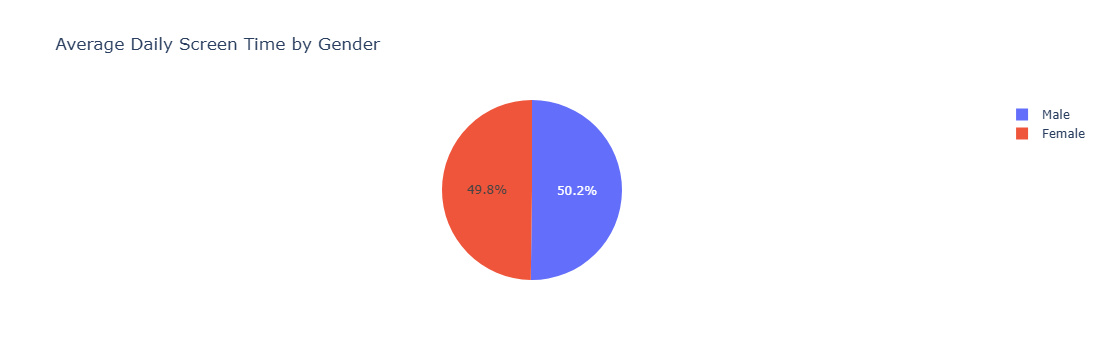

In [45]:
#To analyze the average screen time per gender and compare the distribution of screen time between genders.


avg_screen = df.groupby("Gender")["Avg_Daily_Screen_Time_hr"].mean().reset_index()

fig = px.pie(avg_screen, 
             names="Gender", 
             values="Avg_Daily_Screen_Time_hr", 
             title="Average Daily Screen Time by Gender")

fig.show()


The pie chart indicates that both genders contribute almost equally to the distribution, 
with nearly the same average daily screen time

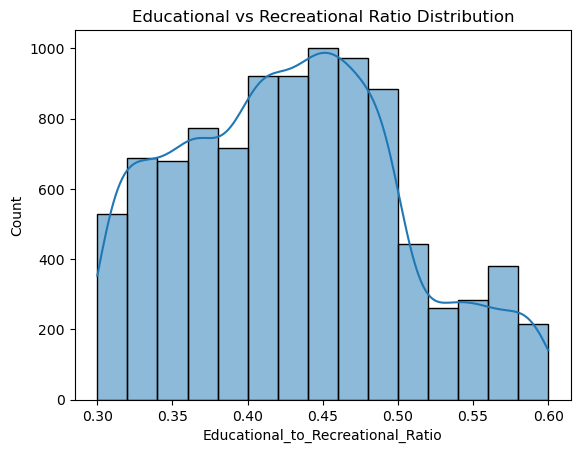

In [47]:
#To analyze how balanced people’s screen time is between educational and recreational purposes
sns.histplot(data=df, x='Educational_to_Recreational_Ratio', bins=15, kde=True)
plt.title("Educational vs Recreational Ratio Distribution")
plt.show()

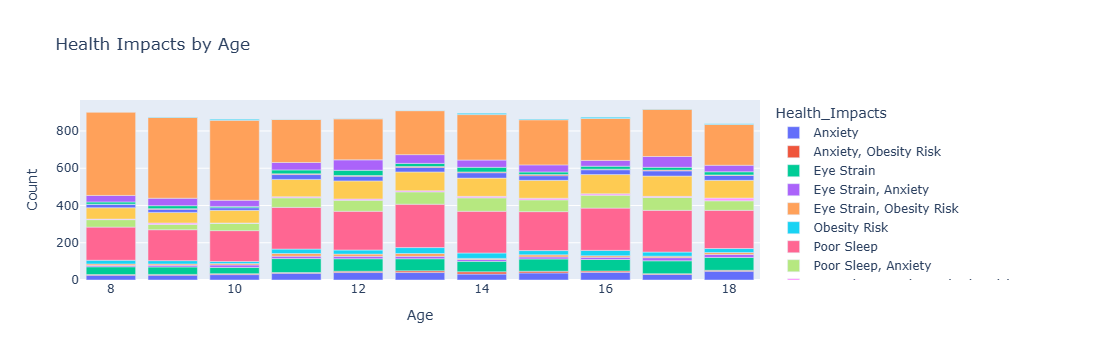

In [48]:
""""To analyze how different health impacts vary across age groups and 
identify which issues are more common at specific ages."""
health_age_count = df.groupby(["Age", "Health_Impacts"]).size().reset_index(name="Count")
fig = px.bar(health_age_count, x="Age", y="Count", color="Health_Impacts", 
             title="Health Impacts by Age")
fig.show()

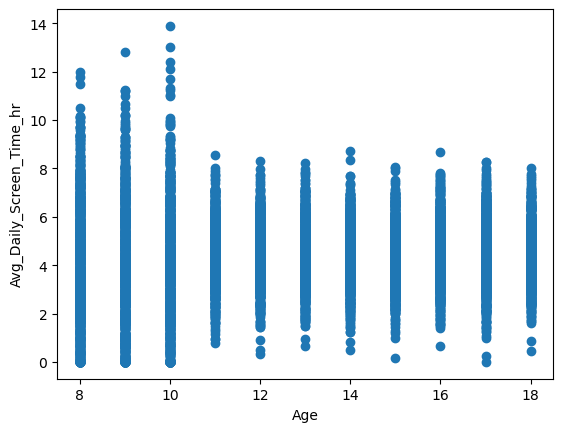

In [49]:
#To analyze how average daily screen time varies across different age groups.
plt.scatter(df['Age'],df['Avg_Daily_Screen_Time_hr'])
plt.xlabel("Age")
plt.ylabel("Avg_Daily_Screen_Time_hr")
plt.show()

The above scatter plot indicates that Age 10 shows the highest average daily screen time(14hours) compared to other age groups 

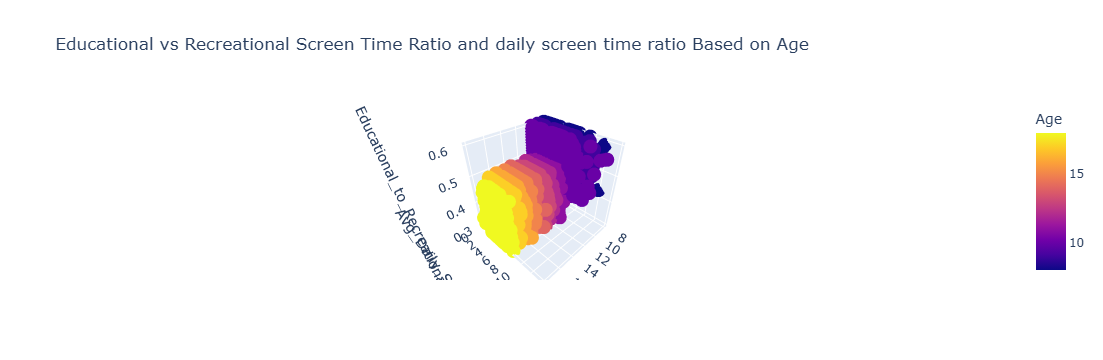

In [51]:
#To analysis how average daily screen time and the ratio of educational to recreational use vary with age
fig=px.scatter_3d(df,x='Age',y='Avg_Daily_Screen_Time_hr',z='Educational_to_Recreational_Ratio'
                  ,color='Age',
                  title='Educational vs Recreational Screen Time Ratio and daily screen time ratio Based on Age')
fig.show()

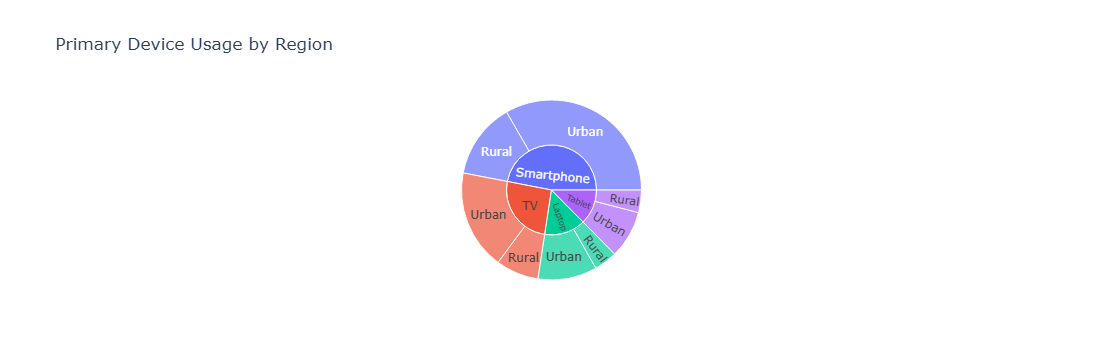

In [52]:
# To analysis  which primary devices have the highest usage across urban and rural regions.
primary_device_region=df.groupby(['Primary_Device','Urban_or_Rural']).size().reset_index(name="Count")
fig=px.sunburst(primary_device_region,path=['Primary_Device','Urban_or_Rural'],
                values='Count',
               title='Primary Device Usage by Region')
fig.show()

smartphone is widely used device in both rural and urban region